# 2 — Seven ways to estimate a price elasticity

Notebook 1 established that the naive regression fails for two separate reasons —
confounding and heterogeneity weighting — and that only the semi-synthetic panel can tell
us whether a fix worked. This notebook introduces the estimators and shows what each one
recovers.

They are ordered by how much structure they impose, from most to least:

| # | model | assumes | gives |
|---|---|---|---|
| 1 | `PooledLogLog` | constant elasticity; controls enter linearly | one number |
| 2 | `TwoWayFixedEffects` | constant elasticity; product and week effects additive | one number |
| 3 | `PoissonGLM` | constant elasticity; multiplicative demand, count outcome | one number |
| 4 | `LightGBMDemand` | nothing about functional form | a number per row |
| 5 | `DoubleMLPartialling` | constant elasticity; nuisances learnable | one number, orthogonal |
| 6 | `RLearnerHeterogeneous` | nothing; nuisances learnable | a number per row, orthogonal |
| 7 | `ShrunkPerProduct` | elasticity varies by product only | a number per product |

**The claim this notebook tests:** flexibility alone does not buy you a better elasticity.
The most flexible predictive model in the list is among the *worst* at recovering the
truth, and the reason is structural, not a tuning accident.

In [1]:
import sys, pathlib, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from elasticity_lab.bench import real_frame, synth_frame, frame_summary
from elasticity_lab.models import (MODEL_REGISTRY, build_model, perturb_price,
                                   PooledLogLog, TwoWayFixedEffects, PoissonGLM,
                                   LightGBMDemand, DoubleMLPartialling,
                                   RLearnerHeterogeneous, ShrunkPerProduct)
from elasticity_lab.evaluation import elasticity_summary, oracle_metrics
from elasticity_lab.features import CONTROL_FEATURES, PRICE_FEATURES, OUTCOME, TREATMENT

pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})
INK, ACCENT, WARN, GOOD = "#3a3a3a", "#1f6feb", "#c0392b", "#1a7f5a"

## 2.0 The two frames

`N_PRODUCTS` subsamples **whole products** so the notebook runs in minutes. Set it to
`None` to reproduce the full-scale numbers quoted in `docs/ELASTICITY_MODELS.md`;
subsampling changes the magnitudes slightly and none of the conclusions.

In [2]:
N_PRODUCTS = 800

real = real_frame(N_PRODUCTS)
syn  = synth_frame(N_PRODUCTS, confounding_price=0.6, confounding_demand=0.8)
pd.concat([frame_summary(real).rename("real"),
           frame_summary(syn).rename("semi-synthetic")], axis=1)

,real,semi-synthetic
rows,43427,43427
products,800,800
weeks,103,103
first_week,2009-12-07,2009-12-07
last_week,2011-12-05,2011-12-05
median_weeks_per_product,49.0,49.0
sd_log_price_within_product,0.222575,0.476906
source,UCI Online Retail II,"semi-synthetic (UCI prices, simulated demand)"
true_mean_elasticity,NaN,1.6617
true_sd_elasticity,NaN,0.7097


## 2.1 Model 1 — pooled log-log OLS

$$\log q = a - \varepsilon \log p + c'X + u$$

The baseline. With controls it is already a large improvement on the two-variable version,
but it still assumes (a) one elasticity for everything and (b) that the controls enter
linearly — and in our synthetic world the confounder is a *nonlinear* function of the
controls, so a linear specification cannot remove it.

In [3]:
m1 = PooledLogLog(use_controls=True).fit(syn)
m1_nc = PooledLogLog(use_controls=False).fit(syn)
print(f"true mean elasticity        : {syn.true_elasticity.mean():+.4f}")
print(f"pooled OLS, no controls     : {m1_nc.average_elasticity:+.4f}")
print(f"pooled OLS, linear controls : {m1.average_elasticity:+.4f}")

true mean elasticity        : +1.6617
pooled OLS, no controls     : +1.1186
pooled OLS, linear controls : +0.9077


## 2.2 Model 2 — two-way fixed effects

$$\log q_{it} = \alpha_i + \gamma_t - \varepsilon \log p_{it} + c'X_{it} + u_{it}$$

$\alpha_i$ absorbs everything permanent about product $i$ (quality, brand, shelf position);
$\gamma_t$ absorbs everything common to week $t$ (season, the Christmas rush, a macro
shock). What identifies $\varepsilon$ is only the *within-product, within-week* price
movement — much closer to a controlled comparison, and the reason this is the workhorse of
applied demand estimation.

Implemented by iterative demeaning (the Frisch–Waugh–Lovell theorem says this gives the
same slope as including 800+ dummy columns, at a fraction of the cost).

In [4]:
m2 = TwoWayFixedEffects(add_controls=True).fit(syn)
print(f"two-way FE : {m2.average_elasticity:+.4f}   "
      f"(true {syn.true_elasticity.mean():+.4f})")

# how much do the fixed effects actually absorb?
for k in (1, 2, 4, 8, 16):
    print(f"  n_iter={k:2d}: {TwoWayFixedEffects(n_iter=k).fit(syn).average_elasticity:+.4f}")

two-way FE : +0.9829   (true +1.6617)


  n_iter= 1: +0.9801


  n_iter= 2: +0.7346


  n_iter= 4: +0.9829


  n_iter= 8: +0.9829


  n_iter=16: +0.9829


Four passes are enough; after that the estimate does not move. The value at
`n_iter=2` is *further* from the converged answer than the value at `n_iter=1` — alternating
projections do not approach their limit monotonically in an unbalanced panel, which is worth
knowing before anyone reads a single low-iteration run as meaningful. `n_iter` is in the
search space in notebook 3, and the search rediscovering "4 is enough" is a small sanity
check on the search itself.

## 2.3 Model 3 — Poisson GLM

$$E[q \mid p, X] = \exp(a - \varepsilon \log p + c'X)$$

Every model above takes $\log q$ as the outcome, which quietly assumes additive errors on
the log scale and mishandles small counts (and cannot handle zeros at all). Quantities are
counts; a log-link Poisson keeps the multiplicative reading — $-b$ is still the elasticity
— while modelling the outcome on its natural scale, and it stays consistent under
multiplicative demand shocks, which is what a demand system actually has.

Fitted by L-BFGS rather than IRLS: IRLS weights equal the fitted mean, so with weekly
quantities in the thousands the working Hessian is badly conditioned and the solver
crawls.

In [5]:
t0 = time.time(); m3 = PoissonGLM().fit(syn)
print(f"Poisson GLM : {m3.average_elasticity:+.4f}  "
      f"({time.time()-t0:.1f}s, {m3.n_iter_} L-BFGS iterations)")

Poisson GLM : +1.9535  (9.4s, 138 L-BFGS iterations)


## 2.4 Model 4 — gradient-boosted demand surface (the S-learner)

Fit one flexible model $\hat f(X, \log p)$ of log quantity on **everything**, then read off
the derivative numerically:

$$\hat\varepsilon(x) = -\frac{\hat f(x, \log p + \delta) - \hat f(x, \log p - \delta)}{2\delta}$$

This is the "S-learner" (single model). It is what a machine-learning practitioner reaches
for first, and it predicts far better than anything above it.

### The trap in the finite difference

`rel_price`, `price_change` and `is_discounted` are all **functions of** `log_price`. A
naive perturbation that moves `log_price` alone holds the discount depth fixed while
changing the price — which is not a price change, and the derivative it measures is not
the elasticity. `perturb_price` moves all of them together.

In [6]:
chk = real.head(500)
bad  = chk.assign(log_price=chk.log_price + 0.10)      # the wrong way
good = perturb_price(chk, 0.10)                        # the right way
mm = LightGBMDemand().fit(real)
d_bad  = -(mm.predict_log_qty(bad)  - mm.predict_log_qty(chk)) / 0.10
d_good = -(mm.predict_log_qty(good) - mm.predict_log_qty(chk)) / 0.10
print(f"elasticity from an inconsistent perturbation : {d_bad.mean():+.4f}")
print(f"elasticity from a consistent perturbation    : {d_good.mean():+.4f}")
print(f"    -> the shortcut is off by {abs(d_good.mean()-d_bad.mean()):.4f}, "
      f"{abs(d_good.mean()-d_bad.mean())/abs(d_good.mean()):.0%} of the answer")

elasticity from an inconsistent perturbation : +0.1377
elasticity from a consistent perturbation    : +1.0433
    -> the shortcut is off by 0.9056, 87% of the answer


In [7]:
m4 = LightGBMDemand().fit(syn)
print(f"LightGBM S-learner : mean {m4.average_elasticity:+.4f}  "
      f"(true {syn.true_elasticity.mean():+.4f})")
pd.Series(elasticity_summary(m4.elasticity(syn))).round(4)

LightGBM S-learner : mean +1.0430  (true +1.6617)


mean             1.0430
sd               0.9926
p5              -0.1219
median           0.8635
p95              2.8173
pct_negative     0.0798
pct_inelastic    0.5595
dtype: float64

## 2.5 Model 5 — Double ML, partialling out

Robinson's (1988) partially-linear model, with the nuisance functions learned rather than
assumed. Write

$$\log q = \theta \log p + g(X) + \eta, \qquad \log p = m(X) + \nu .$$

Learn $\hat g = \hat E[\log q \mid X]$ and $\hat m = \hat E[\log p \mid X]$, take residuals,
and regress one on the other:

$$\hat\theta = \frac{\langle \log p - \hat m,\; \log q - \hat g\rangle}{\langle \log p - \hat m,\; \log p - \hat m\rangle}, \qquad \hat\varepsilon = -\hat\theta .$$

Two properties make this different in kind from the S-learner:

* **Neyman orthogonality** — the estimating equation's derivative with respect to the
  nuisance functions is zero at the truth, so a *first-order* error in $\hat g$ or $\hat m$
  costs only a *second-order* error in $\hat\theta$. Nothing similar is true of reading a
  derivative off a fitted surface.
* **Cross-fitting** — nuisances are predicted out-of-fold, so the model's own overfitting
  cannot leak into the residuals. Here folds are formed **by product**, the version of
  sample splitting that suits a panel.

Chernozhukov, Chetverikov, Demirer, Duflo, Hansen, Newey & Robins (2018).

Double ML : +1.2685 +/- 0.0854 (95%)   [11s]
true      : +1.6617


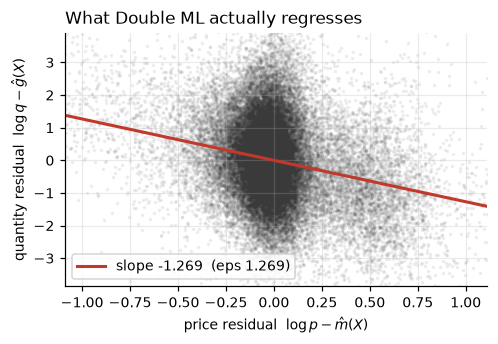

In [8]:
t0 = time.time(); m5 = DoubleMLPartialling(n_folds=5).fit(syn)
print(f"Double ML : {m5.average_elasticity:+.4f} +/- {1.96*m5.se_:.4f} (95%)   "
      f"[{time.time()-t0:.0f}s]")
print(f"true      : {syn.true_elasticity.mean():+.4f}")

fig, ax = plt.subplots(figsize=(4.6, 3.2))
ax.scatter(m5.resid_["rt"], m5.resid_["ry"], s=2, alpha=.06, color=INK)
xs = np.linspace(*np.percentile(m5.resid_["rt"], [0.5, 99.5]), 50)
ax.plot(xs, m5.theta_ * xs, color=WARN, lw=2,
        label=f"slope {m5.theta_:+.3f}  (eps {-m5.theta_:.3f})")
ax.set_xlabel("price residual  $\\log p - \\hat m(X)$")
ax.set_ylabel("quantity residual  $\\log q - \\hat g(X)$")
ax.set_title("What Double ML actually regresses", loc="left"); ax.legend()
ax.set_xlim(*np.percentile(m5.resid_["rt"], [0.5, 99.5]))
ax.set_ylim(*np.percentile(m5.resid_["ry"], [0.5, 99.5]))
fig.tight_layout()

That scatter is the whole method in one picture: after removing everything the controls
can explain from *both* variables, whatever price–quantity relationship is left is the
elasticity.

## 2.6 Model 6 — the R-learner (heterogeneous)

Same residuals, different final stage. Instead of one slope, minimise

$$\sum_i \bigl(\tilde y_i - \theta(x_i)\,\tilde t_i\bigr)^2$$

over functions $\theta(\cdot)$. Algebraically this is a **weighted regression** of the
pseudo-outcome $\tilde y_i / \tilde t_i$ on $x_i$ with weights $\tilde t_i^2$ — and the
weights are the point. A product whose price barely moved has $\tilde t \approx 0$, an
essentially undefined pseudo-outcome, and near-zero weight. The method automatically
ignores the rows that contain no information rather than being misled by them.

Nie & Wager (2021).

In [9]:
t0 = time.time(); m6 = RLearnerHeterogeneous(n_folds=5).fit(syn)
print(f"R-learner : mean {m6.average_elasticity:+.4f}  "
      f"sd {np.std(m6.elasticity(syn)):.4f}   [{time.time()-t0:.0f}s]")
print(f"true      : mean {syn.true_elasticity.mean():+.4f}  "
      f"sd {syn.true_elasticity.std():.4f}")

R-learner : mean +1.2144  sd 1.5267   [13s]
true      : mean +1.6617  sd 0.7097


## 2.7 Model 7 — per-product slopes with empirical-Bayes shrinkage

Run one within-product regression per SKU. On its own this is hopeless: a product with 20
weeks and little price movement produces a slope with an enormous standard error, sometimes
of the wrong sign. Empirical Bayes rescues it by pulling each slope toward the pooled mean
in proportion to its own noise:

$$\hat\varepsilon_i^{\text{shrunk}} = w_i\,\hat\varepsilon_i^{\text{raw}} + (1-w_i)\,\bar\varepsilon,
\qquad w_i = \frac{\tau^2}{\tau^2 + \mathrm{se}_i^2}$$

where $\tau^2$ — the across-product variance of the *true* slopes — is estimated by method
of moments as (observed variance of the raw slopes) − (average sampling variance). A
product whose price never moved gets $w_i \approx 0$ and lands on the pooled mean, which is
the honest answer for it.

products with an estimable raw slope : 800 / 800
tau^2 (across-product variance)      : 0.6268
median shrinkage weight              : 0.911

raw slopes    : mean +0.524  sd 0.843  pct wrong sign 27.3%
shrunk slopes : mean +0.545  sd 0.749  pct wrong sign 23.0%


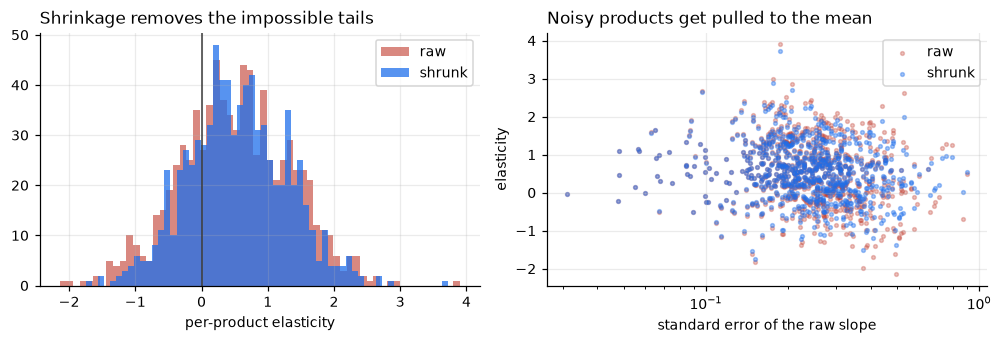

In [10]:
m7 = ShrunkPerProduct().fit(syn)
print(f"products with an estimable raw slope : {len(m7.raw_)} / "
      f"{syn.stock_code.nunique()}")
print(f"tau^2 (across-product variance)      : {m7.tau2_:.4f}")
print(f"median shrinkage weight              : {m7.weights_.median():.3f}")
print(f"\nraw slopes    : mean {-m7.raw_.mean():+.3f}  sd {m7.raw_.std():.3f}  "
      f"pct wrong sign {(m7.raw_ > 0).mean():.1%}")
print(f"shrunk slopes : mean {-m7.shrunk_.mean():+.3f}  sd {m7.shrunk_.std():.3f}  "
      f"pct wrong sign {(m7.shrunk_ > 0).mean():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(9.2, 3.2))
ax[0].hist(-m7.raw_.clip(-6, 8), bins=60, alpha=.6, color=WARN, label="raw")
ax[0].hist(-m7.shrunk_.clip(-6, 8), bins=60, alpha=.75, color=ACCENT, label="shrunk")
ax[0].axvline(0, color=INK, lw=1)
ax[0].set_xlabel("per-product elasticity"); ax[0].legend()
ax[0].set_title("Shrinkage removes the impossible tails", loc="left")
ax[1].scatter(m7.se_, -m7.raw_.clip(-6, 8), s=6, alpha=.3, color=WARN, label="raw")
ax[1].scatter(m7.se_, -m7.shrunk_.clip(-6, 8), s=6, alpha=.4, color=ACCENT, label="shrunk")
ax[1].set_xscale("log"); ax[1].set_xlabel("standard error of the raw slope")
ax[1].set_ylabel("elasticity"); ax[1].legend()
ax[1].set_title("Noisy products get pulled to the mean", loc="left")
fig.tight_layout()

## 2.8 All seven, side by side, graded against the truth

Everything so far was in-sample and untuned — the point is the *ordering*, not the
absolute numbers, and notebook 3 does the tuning properly.

In [11]:
rows = []
for name in MODEL_REGISTRY:
    t0 = time.time()
    m = build_model(name).fit(syn)
    e = np.asarray(m.elasticity(syn), float)
    yhat = m.predict_log_qty(syn)
    rows.append({"model": name, "seconds": round(time.time() - t0, 1),
                 "fit_rmse": float(np.sqrt(np.mean((yhat - syn[OUTCOME]) ** 2))),
                 **oracle_metrics(e, syn.true_elasticity.to_numpy(float)),
                 "heterogeneous": bool(np.std(e) > 1e-9)})
zoo = pd.DataFrame(rows).sort_values("oracle_rmse")
zoo[["model", "heterogeneous", "fit_rmse", "pred_mean", "true_mean", "oracle_bias",
     "oracle_rmse", "oracle_corr", "seconds"]] \
   .style.format({c: "{:+.4f}" for c in
                  ["fit_rmse", "pred_mean", "true_mean", "oracle_bias", "oracle_rmse",
                   "oracle_corr"]}).hide(axis="index")

model,heterogeneous,fit_rmse,pred_mean,true_mean,oracle_bias,oracle_rmse,oracle_corr,seconds
poisson_glm,False,+2.3713,+1.9535,+1.6617,+0.2918,+0.7673,+nan,9.600000
dml_partialling,False,+0.5470,+1.2685,+1.6617,-0.3932,+0.8113,+nan,11.700000
twoway_fe,False,+0.6530,+0.9829,+1.6617,-0.6788,+0.9820,+nan,0.800000
pooled_loglog,False,+1.3161,+0.9077,+1.6617,-0.7540,+1.0355,+nan,0.100000
lgbm_demand,True,+0.5021,+1.0430,+1.6617,-0.6187,+1.1711,+0.3551,2.000000
shrunk_per_product,True,+0.8428,+0.5753,+1.6617,-1.0864,+1.2246,+0.7020,1.200000
r_learner,True,+0.5470,+1.2144,+1.6617,-0.4473,+1.5627,+0.2734,12.800000


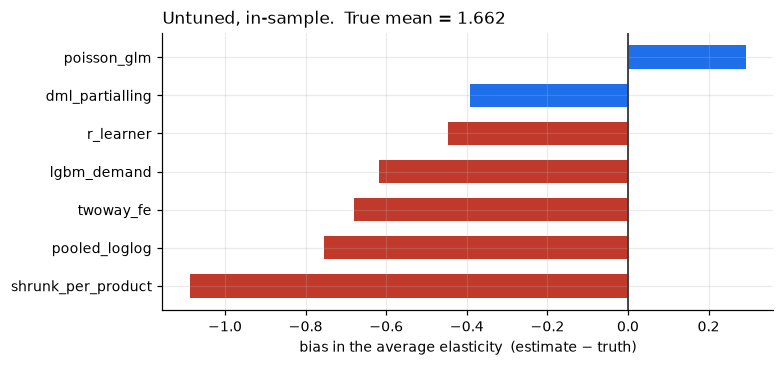

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
z = zoo.sort_values("oracle_bias")
cols = [GOOD if abs(b) < 0.15 else (ACCENT if abs(b) < 0.4 else WARN)
        for b in z.oracle_bias]
ax.barh(z.model, z.oracle_bias, color=cols, height=.62)
ax.axvline(0, color=INK, lw=1.2)
ax.set_xlabel("bias in the average elasticity  (estimate − truth)")
ax.set_title(f"Untuned, in-sample.  True mean = {syn.true_elasticity.mean():.3f}",
             loc="left")
fig.tight_layout()

## 2.9 Reading the table

Four things, all of which set up notebook 3. **Nothing here is tuned** — these are library
defaults on one subsample, so read the pattern, not the decimals.

**The flexible predictive model is not the accurate one.** `lgbm_demand` has the lowest
`fit_rmse` in the table and sits fifth of seven on `oracle_rmse`. This is not bad luck. The
boosting objective spends its capacity wherever squared error falls fastest, and in this
panel price explains a small share of the variance in `log q` next to product identity,
seasonality and last week's sales. Flattening the price dimension is a *good move* for
prediction; nothing in the loss says otherwise. That is the whole problem, and notebook 3 is
about fixing it.

**Orthogonalisation is what fixes the level.** `dml_partialling` uses the same gradient
boosting, the same features and the same hyperparameters as `lgbm_demand`, and cuts the bias
by a third — because the price effect comes from *residuals* rather than from a derivative
of a fitted surface. On the full panel (`experiments/10_model_zoo_smoke.py`, 3,218 products)
the gap is far starker: bias **-0.074** for Double ML against **-0.578** for the S-learner.

**Heterogeneity is expensive in data.** `r_learner` is the worst model in the table here,
and its predicted spread (sd ~1.5) is more than twice the true one (~0.7). It is the same
orthogonal score as `dml_partialling` plus a second-stage model of `eps(x)`, and that second
stage is fitting noise at this sample size. It is not a broken method — on the full panel it
lands at bias -0.133 — it is a method that needs more data than its constant-effect sibling,
and the constant-effect sibling is the right default until you can show otherwise.

**Getting the mean right and getting the ranking right are different achievements.**
`oracle_bias` measures the first, `oracle_corr` the second, and the two best models are
different models. `shrunk_per_product` has the **best rank correlation in the table** and
the **worst bias**; `dml_partialling` has a good bias and, being constant, no ranking at
all. Which you need depends on the decision — one average price move, or a different move
per product — and notebook 4 measures both.

## 2.10 The same models on the real panel

No ground truth here — this is the situation you are actually in. The estimates disagree,
and nothing in this table says which is right. Notebook 3 supplies an *observable*
criterion for choosing.

In [13]:
rows = []
for name in MODEL_REGISTRY:
    m = build_model(name).fit(real)
    e = np.asarray(m.elasticity(real), float)
    rows.append({"model": name, **elasticity_summary(e)})
pd.DataFrame(rows).style.format(
    {c: "{:+.3f}" for c in ["mean", "sd", "p5", "median", "p95"]}
).format({"pct_negative": "{:.1%}", "pct_inelastic": "{:.1%}"}).hide(axis="index")

model,mean,sd,p5,median,p95,pct_negative,pct_inelastic
pooled_loglog,1.489752,0.000000,1.489752,1.489752,1.489752,0.0%,0.0%
twoway_fe,1.487369,0.000000,1.487369,1.487369,1.487369,0.0%,0.0%
poisson_glm,1.673003,0.000000,1.673003,1.673003,1.673003,0.0%,0.0%
lgbm_demand,2.927180,2.251297,-0.242506,2.671220,7.102427,6.7%,18.5%
dml_partialling,1.039452,0.000000,1.039452,1.039452,1.039452,0.0%,0.0%
r_learner,1.184009,1.062833,-0.205377,1.212203,2.692288,6.2%,35.6%
shrunk_per_product,1.800198,0.730566,0.628450,1.791803,3.045171,0.8%,12.3%


`pct_negative` is a free sanity check: an elasticity below zero says demand rises when
you raise the price. A few such products may be genuine (luxury signalling, or a price rise
that coincided with a promotion we failed to control for), but a model producing many of
them is telling you its heterogeneity is noise.

**Next:** `03_hyperparameter_optimization.ipynb` — how to tune these when the thing you
care about is not the thing you can measure.